# ARIMA Model 
## Article 147807


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima
import warnings
warnings.filterwarnings('ignore')

## 1. Load and Prepare Data

In [2]:
# Load data
df = pd.read_csv("../data_raw/date_24_art_loreal_20%.csv")
df = df[df["ID_ARTICOL"] == 147807]


# Convert DATA column to datetime
df['DATA'] = pd.to_datetime(df['DATA'], errors="coerce")

# Sort by date
df = df.sort_values(by=["DATA"]).reset_index(drop=True)

print(f"Data shape: {df.shape}")
print(f"Date range: {df['DATA'].min()} to {df['DATA'].max()}")
print(f"\nFirst few rows:")
print(df.head())


Data shape: (735, 13)
Date range: 2024-01-01 00:00:00 to 2026-01-04 00:00:00

First few rows:
        DATA  ID_ARTICOL                                            ARTICOL  \
0 2024-01-01      147807  LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...   
1 2024-01-02      147807  LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...   
2 2024-01-03      147807  LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...   
3 2024-01-04      147807  LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...   
4 2024-01-05      147807  LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...   

   CANTITATE  VAL_IESIRE_FARA_TVA  VAL_IESIRE_CU_TVA  VAL_INTRARE_FARA_TVA  \
0          0                 0.00                0.0                  0.00   
1          0                 0.00                0.0                  0.00   
2         11               647.00              770.0                574.75   
3         11               647.04              770.0                574.75   
4         10               588.22        

In [4]:
df.describe()

,DATA,ID_ARTICOL,CANTITATE,VAL_IESIRE_FARA_TVA,VAL_IESIRE_CU_TVA,VAL_INTRARE_FARA_TVA,TOTAL_DISCOUNT,RATA_DISCOUNT,ADAOS,STOC_INITIAL,STOC_FINAL,RUPTURA_STOC
count,735,735.0,735.000000,735.000000,735.000000,735.000000,735.000000,704.000000,735.000000,735.000000,735.000000,735.0
mean,2025-01-01 23:59:59.999999744,147807.0,12.378231,646.565102,772.189701,645.127551,110.373088,0.095478,1.437551,341.500680,343.032653,0.0
min,2024-01-01 00:00:00,147807.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-755.080000,38.000000,38.000000,0.0
25%,2024-07-02 12:00:00,147807.0,7.000000,417.630000,497.000000,365.750000,0.000000,0.000000,-58.760000,204.000000,204.000000,0.0
50%,2025-01-02 00:00:00,147807.0,11.000000,596.620000,710.000000,574.750000,0.000000,0.000000,46.020000,271.000000,271.000000,0.0
75%,2025-07-04 12:00:00,147807.0,15.000000,801.810000,958.500000,783.750000,195.250000,0.250000,74.125000,366.000000,366.500000,0.0
max,2026-01-04 00:00:00,147807.0,75.000000,3325.640000,4023.750000,3918.750000,1533.600000,0.700000,1029.240000,1577.000000,1577.000000,0.0
std,NaN,0.0,9.275150,390.917692,467.678411,484.778830,222.537500,0.152401,131.191129,263.160511,266.051928,0.0


In [3]:
# Extract time series for CANTITATE
ts = df.set_index('DATA')['CANTITATE'].astype(float).sort_index()

# Check for missing values
print(f"Missing values: {ts.isna().sum()}")
print(f"Time series length: {len(ts)}")

# Create train-test split (last 14 days as test)
forecast_horizon_daily = 14
split_idx = len(ts) - forecast_horizon_daily
train = ts.iloc[:split_idx]
test = ts.iloc[split_idx:]

print(f"\nTrain set: {len(train)} observations")
print(f"Test set: {len(test)} observations")


Missing values: 0
Time series length: 735

Train set: 721 observations
Test set: 14 observations


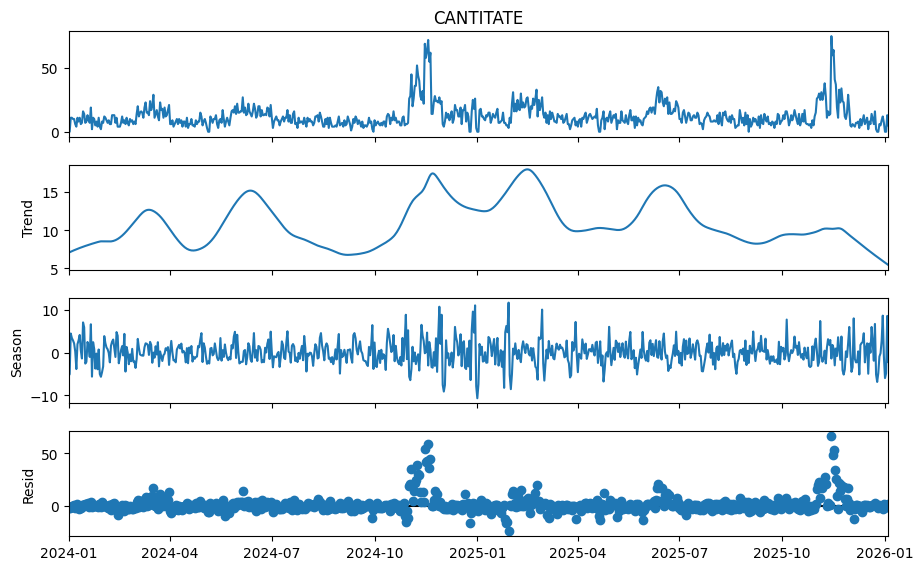

In [4]:
from statsmodels.tsa.seasonal import STL

# STL decomposition (daily series)   STL - Seasonal Trend decomposition using LOESS
stl_series = ts.asfreq('D').interpolate('time').fillna(0)
stl = STL(stl_series, period=30, robust=True)
stl_res = stl.fit()

fig = stl_res.plot()
fig.set_size_inches(10, 6)
plt.show()


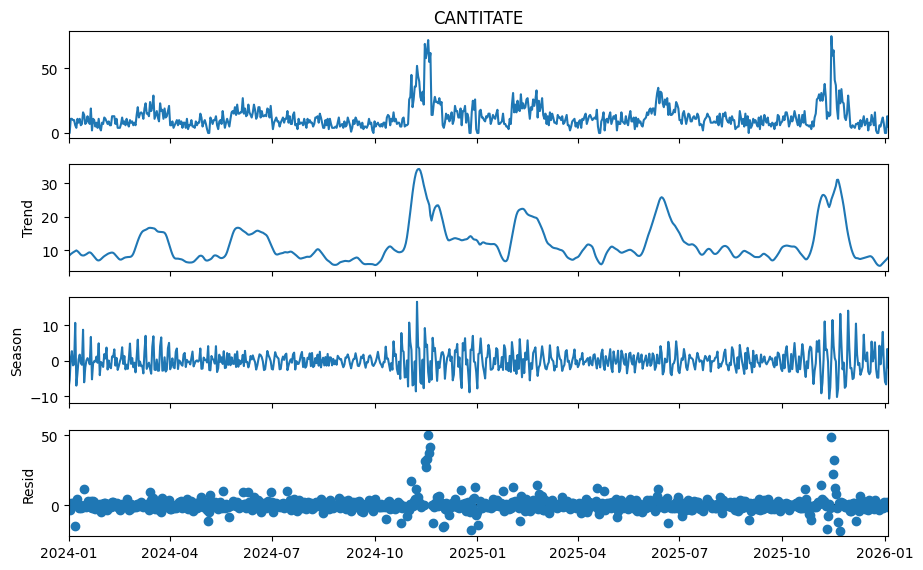

In [5]:
from statsmodels.tsa.seasonal import STL

# STL decomposition (daily series)
stl_series = ts.asfreq('D').interpolate('time').fillna(0)
stl = STL(stl_series, period=7, robust=True)
stl_res = stl.fit()

fig = stl_res.plot()
fig.set_size_inches(10, 6)
plt.show()


## 2. Time Series Visualization

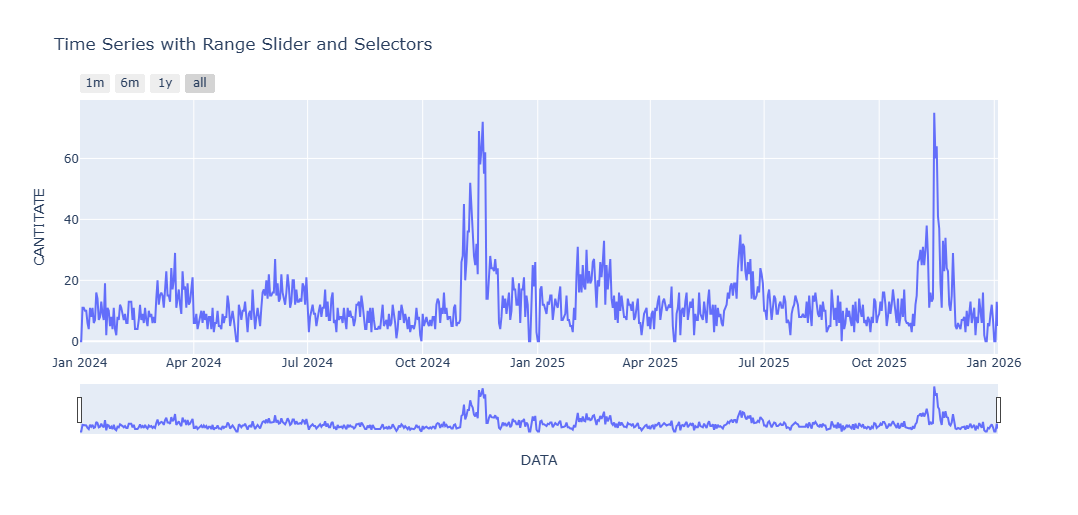

In [6]:
fig = px.line(df, x='DATA', y='CANTITATE', title='Time Series with Range Slider and Selectors')

fig.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
        buttons=list([
            dict(count=1, label="1m", step="month", stepmode="backward"),
            dict(count=6, label="6m", step="month", stepmode="backward"),
            # dict(count=1, label="YTD", step="year", stepmode="todate"),
            dict(count=1, label="1y", step="year", stepmode="backward"),
            dict(step="all")
        ])
    )
)

fig.update_layout(width=1100, height=500)
fig.show()

## 3. Stationarity Testing (ADF & KPSS)

In [7]:
def test_stationarity(timeseries, name=""):
    """Test for stationarity using ADF and KPSS tests"""
    print(f"\n{'='*60}")
    print(f"Stationarity Tests for {name}")
    print(f"{'='*60}")
    
    # ADF Test
    adf_result = adfuller(timeseries.dropna())
    print(f"\nADF Test (Null hypothesis: Series is non-stationary)")
    print(f"  ADF Statistic: {adf_result[0]:.6f}")
    print(f"  p-value: {adf_result[1]:.6f}")
    print(f"  Critical Values:")
    for key, value in adf_result[4].items():
        print(f"    {key}: {value:.3f}")
    
    if adf_result[1] <= 0.05:
        print(f"  ✓ Series is STATIONARY (reject null hypothesis)")
        adf_stationary = True
    else:
        print(f"  ✗ Series is NON-STATIONARY (fail to reject null hypothesis)")
        adf_stationary = False
    
    # KPSS Test
    kpss_result = kpss(timeseries.dropna(), regression='c', nlags='auto')
    print(f"\nKPSS Test (Null hypothesis: Series is stationary)")
    print(f"  KPSS Statistic: {kpss_result[0]:.6f}")
    print(f"  p-value: {kpss_result[1]:.6f}")
    print(f"  Critical Values:")
    for key, value in kpss_result[3].items():
        print(f"    {key}: {value:.3f}")
    
    if kpss_result[1] >= 0.05:
        print(f"  ✓ Series is STATIONARY (fail to reject null hypothesis)")
        kpss_stationary = True
    else:
        print(f"  ✗ Series is NON-STATIONARY (reject null hypothesis)")
        kpss_stationary = False
    
    print(f"\nConclusion: Series is {'STATIONARY' if (adf_stationary and kpss_stationary) else 'NON-STATIONARY'}")
    
    return adf_stationary and kpss_stationary

# Test original series
is_stationary = test_stationarity(train, "Original Training Series")


Stationarity Tests for Original Training Series

ADF Test (Null hypothesis: Series is non-stationary)
  ADF Statistic: -5.193721
  p-value: 0.000009
  Critical Values:
    1%: -3.440
    5%: -2.866
    10%: -2.569
  ✓ Series is STATIONARY (reject null hypothesis)

KPSS Test (Null hypothesis: Series is stationary)
  KPSS Statistic: 0.185955
  p-value: 0.100000
  Critical Values:
    10%: 0.347
    5%: 0.463
    2.5%: 0.574
    1%: 0.739
  ✓ Series is STATIONARY (fail to reject null hypothesis)

Conclusion: Series is STATIONARY


In [8]:
# Test differenced series if not stationary
if not is_stationary:
    train_diff = train.diff().dropna()
    is_diff_stationary = test_stationarity(train_diff, "First Differenced Series")
    
    if not is_diff_stationary:
        train_diff2 = train_diff.diff().dropna()
        is_diff2_stationary = test_stationarity(train_diff2, "Second Differenced Series")
        d_order = 2
    else:
        d_order = 1
else:
    d_order = 0

print(f"\n{'='*60}")
print(f"Recommended differencing order (d): {d_order}")
print(f"{'='*60}")


Recommended differencing order (d): 0


## 4. ACF and PACF Plots for Parameter Identification

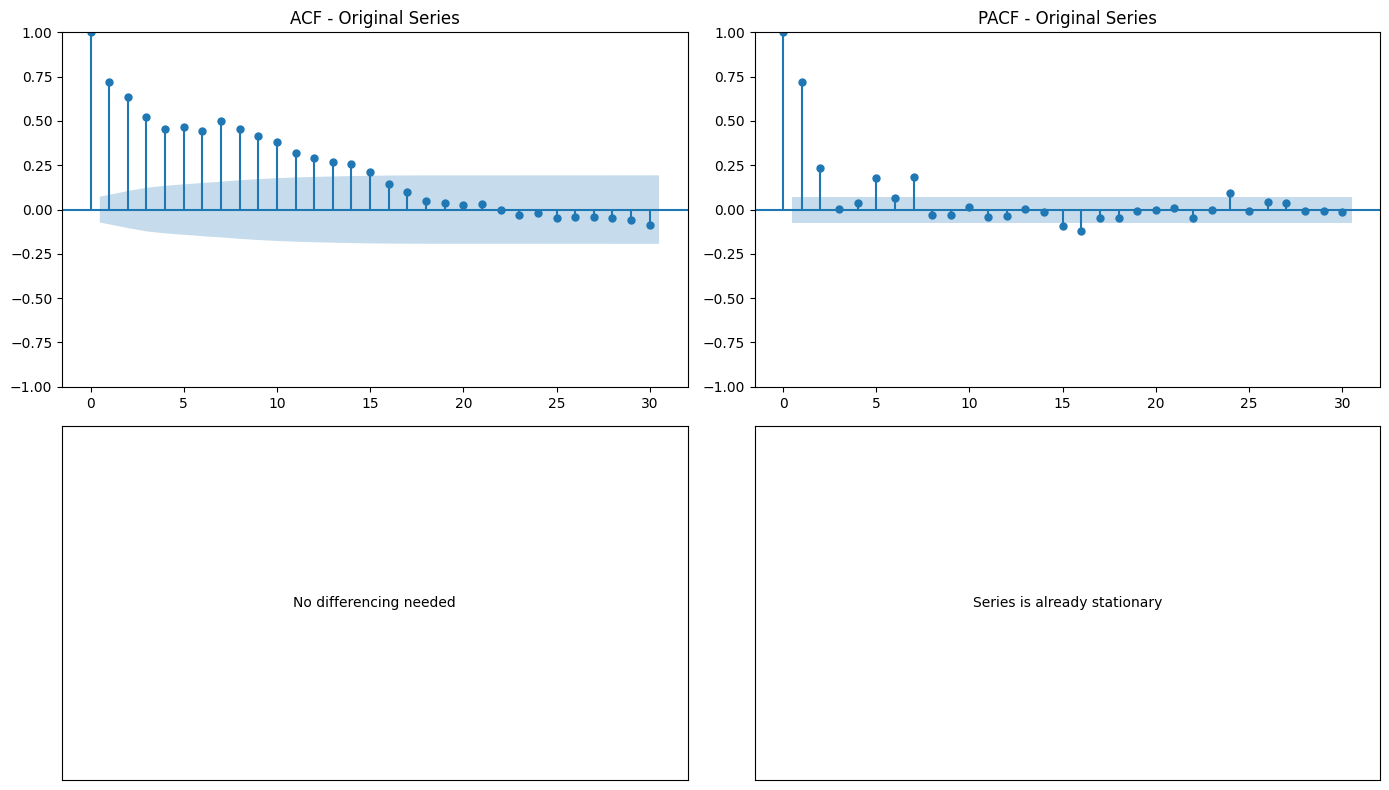


ACF/PACF Analysis:
- ACF (AutoCorrelation Function): Shows correlation with past values
- PACF (Partial AutoCorrelation Function): Shows direct correlation after removing intermediate lags
- Use these plots to guide p and q parameter selection


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# ACF and PACF for original series
plot_acf(train.dropna(), lags=30, ax=axes[0, 0], title='ACF - Original Series')
plot_pacf(train.dropna(), lags=30, ax=axes[0, 1], title='PACF - Original Series')

# ACF and PACF for differenced series
if d_order > 0:
    train_diff = train.diff().dropna()
    plot_acf(train_diff, lags=30, ax=axes[1, 0], title=f'ACF - {d_order}st Differenced')
    plot_pacf(train_diff, lags=30, ax=axes[1, 1], title=f'PACF - {d_order}st Differenced')
else:
    axes[1, 0].text(0.5, 0.5, 'No differencing needed', ha='center', va='center')
    axes[1, 1].text(0.5, 0.5, 'Series is already stationary', ha='center', va='center')
    axes[1, 0].set_xticks([])
    axes[1, 0].set_yticks([])
    axes[1, 1].set_xticks([])
    axes[1, 1].set_yticks([])

plt.tight_layout()
plt.show()

print("\nACF/PACF Analysis:")
print("- ACF (AutoCorrelation Function): Shows correlation with past values")
print("- PACF (Partial AutoCorrelation Function): Shows direct correlation after removing intermediate lags")
print("- Use these plots to guide p and q parameter selection")

## 5. Auto ARIMA - Automatic Parameter Selection

In [10]:
print("Running Auto ARIMA to find optimal parameters...")
print("This may take a minute...\n")

auto_model = auto_arima(
    train,
    seasonal=False,
    d=d_order,
    max_p=6,
    max_q=6,
    max_d=2,
    stepwise=True,
    suppress_warnings=True,
    trace=False,
    error_action='ignore'
)

auto_order = auto_model.order
print(f"\n{'='*60}")
print(f"Auto ARIMA Optimal Parameters: {auto_order}")
print(f"AIC: {auto_model.aic():.2f}")
print(f"BIC: {auto_model.bic():.2f}")
print(f"{'='*60}")
print(f"\nModel Summary:\n{auto_model.summary()}")

Running Auto ARIMA to find optimal parameters...
This may take a minute...




Auto ARIMA Optimal Parameters: (3, 0, 3)
AIC: 4662.53
BIC: 4699.18

Model Summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  721
Model:               SARIMAX(3, 0, 3)   Log Likelihood               -2323.267
Date:                Thu, 22 Jan 2026   AIC                           4662.534
Time:                        17:42:39   BIC                           4699.179
Sample:                    01-01-2024   HQIC                          4676.680
                         - 12-21-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.4971      0.179      2.772      0.006       0.146       0.849
ar.L1          2.0811      0.076     27.441    

## 6. Manual Grid Search - Test Multiple ARIMA Configurations

In [11]:
def evaluate_arima(order, train_data, test_data):
    """Fit ARIMA model and return evaluation metrics"""
    try:
        model = ARIMA(train_data, order=order)
        fitted = model.fit()

        # Forecast
        predictions = fitted.forecast(steps=len(test_data))

        # Calculate metrics
        mae = mean_absolute_error(test_data, predictions)
        rmse = np.sqrt(mean_squared_error(test_data, predictions))
        mape = mean_absolute_percentage_error(test_data, predictions)
        r2 = r2_score(test_data, predictions)

        # Correlation between actual and predicted
        corr = np.corrcoef(test_data, predictions)[0, 1]

        return {
            'Order': order,
            'AIC': fitted.aic,
            'BIC': fitted.bic,
            'MAE': mae,
            'RMSE': rmse,
            'MAPE': mape,
            'R2': r2,
            'Correlation': corr,
            'Model': fitted
        }
    except Exception:
        return None

print("Evaluating a small set of ARIMA candidates...")

candidate_orders = [
    (6, 1, 0),
    (5, 0, 4),
    (6, 2, 4),
    auto_order,
]
# de-duplicate while preserving order
seen = set()
candidate_orders = [o for o in candidate_orders if not (o in seen or seen.add(o))]

results_list = []
for order in candidate_orders:
    result = evaluate_arima(order, train, test)
    if result is not None:
        results_list.append(result)

results_df = pd.DataFrame([
    {
        'Order': r['Order'],
        'AIC': r['AIC'],
        'BIC': r['BIC'],
        'MAE': r['MAE'],
        'RMSE': r['RMSE'],
        'MAPE': r['MAPE'],
        'R2': r['R2'],
        'Correlation': r['Correlation']
    } for r in results_list
])

print(results_df[['Order', 'AIC', 'MAE', 'RMSE', 'R2']].sort_values('RMSE'))


Evaluating a small set of ARIMA candidates...


       Order          AIC       MAE      RMSE        R2
2  (6, 2, 4)  4673.777600  4.964711  5.547326 -0.208954
0  (6, 1, 0)  4657.868655  5.060918  5.717943 -0.284465
3  (3, 0, 3)  4700.087617  6.133195  6.976469 -0.912114
1  (5, 0, 4)  4647.468612  6.445002  7.481846 -1.199177


In [12]:
print(f"\nTop 10 models by RMSE:")
print(results_df.nsmallest(10, 'RMSE')[['Order', 'AIC', 'MAE', 'RMSE', 'MAPE', 'R2']])

print(f"\nTop 10 models by R²:")
print(results_df.nlargest(10, 'R2')[['Order', 'AIC', 'MAE', 'RMSE', 'MAPE', 'R2']])


Top 10 models by RMSE:
       Order          AIC       MAE      RMSE          MAPE        R2
2  (6, 2, 4)  4673.777600  4.964711  5.547326  1.023608e+16 -0.208954
0  (6, 1, 0)  4657.868655  5.060918  5.717943  1.116477e+16 -0.284465
3  (3, 0, 3)  4700.087617  6.133195  6.976469  1.366836e+16 -0.912114
1  (5, 0, 4)  4647.468612  6.445002  7.481846  1.471552e+16 -1.199177

Top 10 models by R²:
       Order          AIC       MAE      RMSE          MAPE        R2
2  (6, 2, 4)  4673.777600  4.964711  5.547326  1.023608e+16 -0.208954
0  (6, 1, 0)  4657.868655  5.060918  5.717943  1.116477e+16 -0.284465
3  (3, 0, 3)  4700.087617  6.133195  6.976469  1.366836e+16 -0.912114
1  (5, 0, 4)  4647.468612  6.445002  7.481846  1.471552e+16 -1.199177


## 7. Select Best Model by Multiple Criteria

In [13]:
# Select a fixed model for reporting/plotting
selected_order = (5, 0, 4)
print("Selected model for plotting/reporting:", selected_order)


Selected model for plotting/reporting: (5, 0, 4)


## 8. Fit Best Model and Generate Predictions

In [14]:
# Fit the best model
best_model = ARIMA(train, order=selected_order)
best_fitted = best_model.fit()

# Generate predictions on test set
predictions = best_fitted.forecast(steps=len(test))

print(f"Model Summary for Order {selected_order}:")
print(best_fitted.summary())

Model Summary for Order (5, 0, 4):
                               SARIMAX Results                                
Dep. Variable:              CANTITATE   No. Observations:                  721
Model:                 ARIMA(5, 0, 4)   Log Likelihood               -2312.734
Date:                Thu, 22 Jan 2026   AIC                           4647.469
Time:                        17:42:42   BIC                           4697.856
Sample:                    01-01-2024   HQIC                          4666.920
                         - 12-21-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.3668      1.691      7.313      0.000       9.053      15.681
ar.L1          0.9771      0.082     11.929      0.000       0.817       1.138
ar.L2          0.

## 9. Comprehensive Model Evaluation Metrics

In [15]:
def calculate_all_metrics(actual, predicted):
    """Calculate comprehensive evaluation metrics"""
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(actual, predicted)
    r2 = r2_score(actual, predicted)
    
    # Mean Absolute Percentage Error (alternative)
    mape_alt = np.mean(np.abs((actual - predicted) / actual)) * 100
    
    # Correlation
    correlation = np.corrcoef(actual, predicted)[0, 1]
    
    # Mean Percentage Error (bias)
    mpe = np.mean(((actual - predicted) / actual) * 100)
    
    # Normalized RMSE
    nrmse = rmse / np.mean(actual)
    
    # Theil's U statistic (relative to naive forecast)
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)

    if len(actual) < 2 or len(predicted) < 2:
        theils_u = np.nan
    else:
        actual_shifted = actual[1:]
        pred_shifted = predicted[:-1]
        naive_forecast = actual[:-1]
        u_numerator = np.sqrt(np.mean((actual_shifted - pred_shifted) ** 2))
        u_denominator = np.sqrt(np.mean((actual_shifted - naive_forecast) ** 2))
        theils_u = u_numerator / u_denominator if u_denominator != 0 else np.nan
    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE (%)': mape,
        'MAPE Alt (%)': mape_alt,
        'R²': r2,
        'Correlation': correlation,
        'MPE (%)': mpe,
        'NRMSE': nrmse,
        "Theil's U": theils_u
    }

metrics = calculate_all_metrics(test.values, predictions)

print(f"ARIMA {selected_order} | MAE: {metrics['MAE']:.4f} | RMSE: {metrics['RMSE']:.4f}")

print("\n" + "="*70)
print("ARIMA SELECTED MODEL - PERFORMANCE METRICS")
print("="*70)
for metric_name, metric_value in metrics.items():
    if isinstance(metric_value, float):
        if metric_name in ['MAPE (%)', 'MAPE Alt (%)', 'MPE (%)']:
            print(f"{metric_name:.<30} {metric_value:>10.2f}%")
        elif metric_name in ['R²', 'Correlation', 'NRMSE', "Theil's U"]:
            print(f"{metric_name:.<30} {metric_value:>10.4f}")
        else:
            print(f"{metric_name:.<30} {metric_value:>10.4f}")
    else:
        print(f"{metric_name:.<30} {metric_value:>10}")

print("="*70)


ARIMA (5, 0, 4) | MAE: 6.4450 | RMSE: 7.4818

ARIMA SELECTED MODEL - PERFORMANCE METRICS
MAE...........................     6.4450
MSE...........................    55.9780
RMSE..........................     7.4818
MAPE (%)...................... 14715520741298694.00%
MAPE Alt (%)..................        inf%
R²............................    -1.1992
Correlation...................     0.1166
MPE (%).......................       -inf%
NRMSE.........................     1.2932
Theil's U.....................     1.0807


## 10. Visualization - Actual vs Predicted

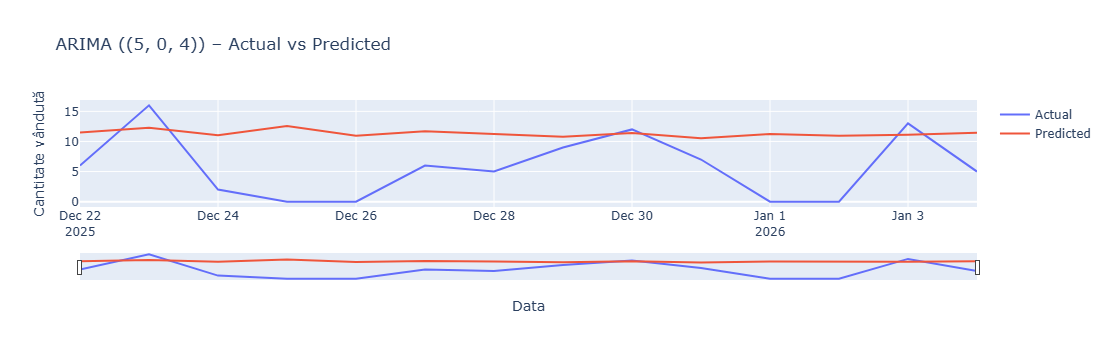

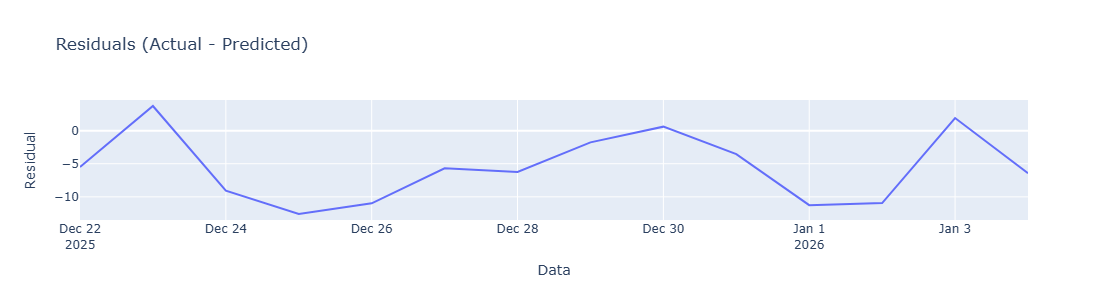

In [16]:
df_plot = pd.DataFrame({
    "DATA": test.index,
    "Actual": test.values,
    "Predicted": predictions
})

df_long = df_plot.melt(id_vars="DATA", value_vars=["Actual", "Predicted"], var_name="Serie", value_name="Cantitate")

fig = px.line(
    df_long,
    x="DATA",
    y="Cantitate",
    color="Serie",
    title=f"ARIMA ({selected_order}) – Actual vs Predicted",
    labels={"DATA": "Data", "Cantitate": "Cantitate vândută"}
)
fig.update_layout(
    xaxis_title="Data",
    yaxis_title="Cantitate vândută",
    hovermode="x unified",
    legend_title_text=""
)
fig.update_xaxes(rangeslider_visible=True)
fig.show()

# Residuals plot
residuals = test.values - predictions
fig2 = px.line(x=test.index, y=residuals, title="Residuals (Actual - Predicted)", labels={"x": "Data", "y": "Residual"})
fig2.update_layout(height=300)
fig2.show()

## 11. Save Results and Model

In [17]:
# Save predictions and metrics
df_plot.to_csv("../figures/arima_94869_predictions.csv", index=False)

import joblib
joblib.dump(best_fitted, "../figures/arima_94869_model.joblib")

print("Results and model saved to ../figures/")

Results and model saved to ../figures/
